### Import the necessary packages

In [34]:
import geopandas as gpd
import rasterio
import pandas as pd
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

### Set the directory and file paths

In [35]:
# Paths — update to your actual locations

RASTER_DIR = r'D:\Research\Flood Susceptibility\Data\Rasters\SensitivityR' + '\\'

POINTS_SHP = r'D:\Research\Flood Susceptibility\Data\hand_label.shp'
OUTPUT_DIR = r'D:\Research\Flood Susceptibility\Data\Rasters\output'

rasters = {
    '-18 dB':     RASTER_DIR + 'composite_flood_t18dB.tif',
    '-20 dB':     RASTER_DIR + 'composite_flood_t20dB.tif',
    '-22 dB':     RASTER_DIR + 'composite_flood_t22dB.tif',
    'Otsu':       RASTER_DIR + 'composite_flood_otsu.tif',
    'Dual-Pol':   RASTER_DIR + 'composite_flood_dualpol.tif',
}


### Load the hand labeled flood and non flood points

In [36]:
# Load reference points

points = gpd.read_file(POINTS_SHP)
coords = [(geom.x, geom.y) for geom in points.geometry]
labels = points['value'].values  # 1=flooded, 0=not flooded

print(f"Total reference points : {len(points)}")
print(f"  Flooded              : {sum(labels == 1)}")
print(f"  Not flooded          : {sum(labels == 0)}")


Total reference points : 200
  Flooded              : 105
  Not flooded          : 95


### Plot the points on the map

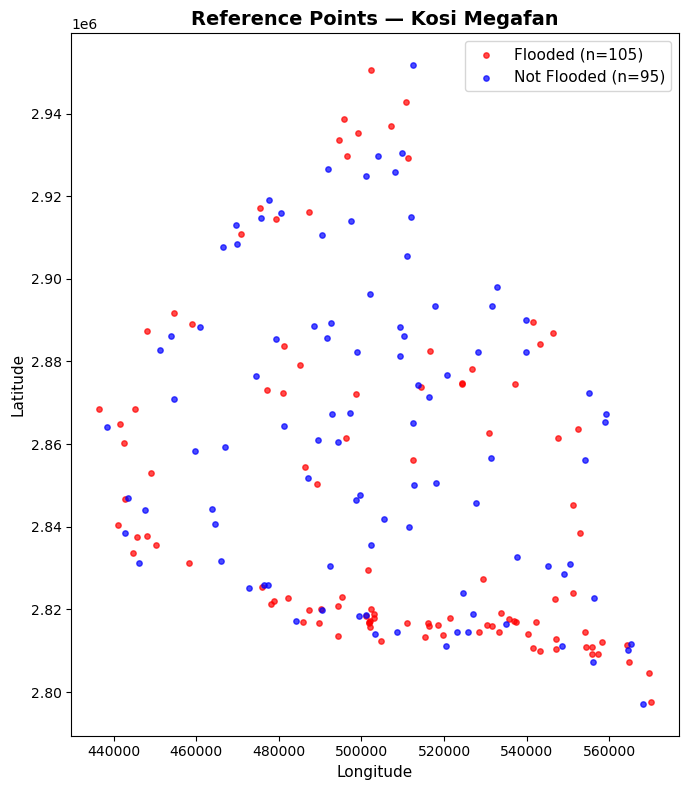

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = {1: 'red', 0: 'blue'}
labels_map = {1: 'Flooded', 0: 'Not Flooded'}

for val, color in colors.items():
    subset = points[points['value'] == val]
    subset.plot(ax=ax, color=color, markersize=15,
                label=f"{labels_map[val]} (n={len(subset)})", alpha=0.7)

ax.set_title('Reference Points — Kosi Megafan', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Sample each raster at reference points

In [37]:
# Sample each raster at reference points

results = pd.DataFrame({'value': labels})

for method, path in rasters.items():
    with rasterio.open(path) as src:
        sampled = [val[0] for val in src.sample(coords)]
        results[method] = sampled

print("\nSample of results:")
print(results)


Sample of results:
     value  -18 dB  -20 dB  -22 dB  Otsu  Dual-Pol
0        0       0       0       0     0         0
1        0       0       0       0     0         0
2        0       0       0       0     0         0
3        1       0       0       0     0         0
4        0       0       0       0     0         0
..     ...     ...     ...     ...   ...       ...
195      1       1       1       1     1         1
196      1       1       1       1     1         1
197      1       1       1       1     1         1
198      1       1       1       1     1         1
199      1       0       0       0     1         0

[200 rows x 6 columns]


### Compute confusion matrix

In [38]:
# Compute confusion matrix and metrics per method

summary = []

for method in rasters.keys():
    preds = results[method].values
    true  = results['value'].values
    cm    = confusion_matrix(true, preds)

    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)

    acc        = accuracy_score(true, preds)
    precision  = precision_score(true, preds, zero_division=0)
    recall     = recall_score(true, preds, zero_division=0)
    f1         = f1_score(true, preds, zero_division=0)
    commission = fp / (tp + fp) if (tp + fp) > 0 else 0
    omission   = fn / (tp + fn) if (tp + fn) > 0 else 0

    summary.append({
        'Method':           method,
        'TP':               int(tp),
        'FP':               int(fp),
        'TN':               int(tn),
        'FN':               int(fn),
        'Overall Acc (%)':  round(acc        * 100, 2),
        'Precision (%)':    round(precision  * 100, 2),
        'Recall (%)':       round(recall     * 100, 2),
        'F1 Score (%)':     round(f1         * 100, 2),
        'Commission (%)':   round(commission * 100, 2),
        'Omission (%)':     round(omission   * 100, 2),
    })


### save summary table

In [39]:
# Print and save summary table

df = pd.DataFrame(summary)
print("\n SENSITIVITY ANALYSIS RESULTS")
print(df.to_string(index=False))
df.to_csv(OUTPUT_DIR + 'sensitivity_analysis_results.csv', index=False)
print(f"\nSaved to: {OUTPUT_DIR}sensitivity_analysis_results.csv")



 SENSITIVITY ANALYSIS RESULTS
  Method  TP  FP  TN  FN  Overall Acc (%)  Precision (%)  Recall (%)  F1 Score (%)  Commission (%)  Omission (%)
  -18 dB  70  13  82  35             76.0          84.34       66.67         74.47           15.66         33.33
  -20 dB  59  10  85  46             72.0          85.51       56.19         67.82           14.49         43.81
  -22 dB  56   9  86  49             71.0          86.15       53.33         65.88           13.85         46.67
    Otsu  86  14  81  19             83.5          86.00       81.90         83.90           14.00         18.10
Dual-Pol  55   9  86  50             70.5          85.94       52.38         65.09           14.06         47.62

Saved to: D:\Research\Flood Susceptibility\Data\Rasters\outputsensitivity_analysis_results.csv


### Plot confusion matrices

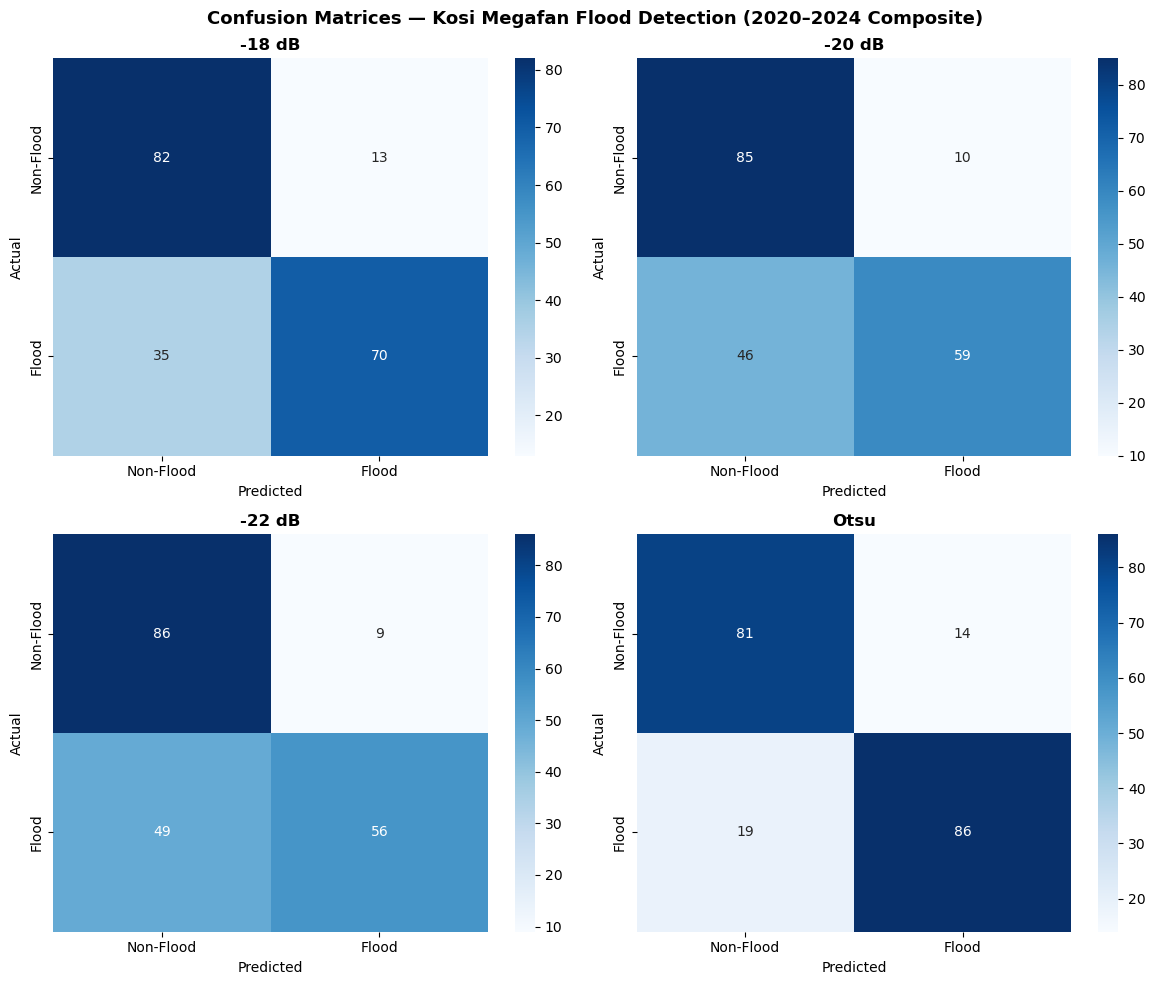

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, method in zip(axes, rasters.keys()):
    preds = results[method].values
    cm    = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Flood','Flood'],
                yticklabels=['Non-Flood','Flood'])
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide unused subplots if rasters < 4
for i in range(len(rasters), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Confusion Matrices — Kosi Megafan Flood Detection (2020–2024 Composite)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'confusion_matrices.png', dpi=600, bbox_inches='tight')
plt.show()


### Metric Compariosn

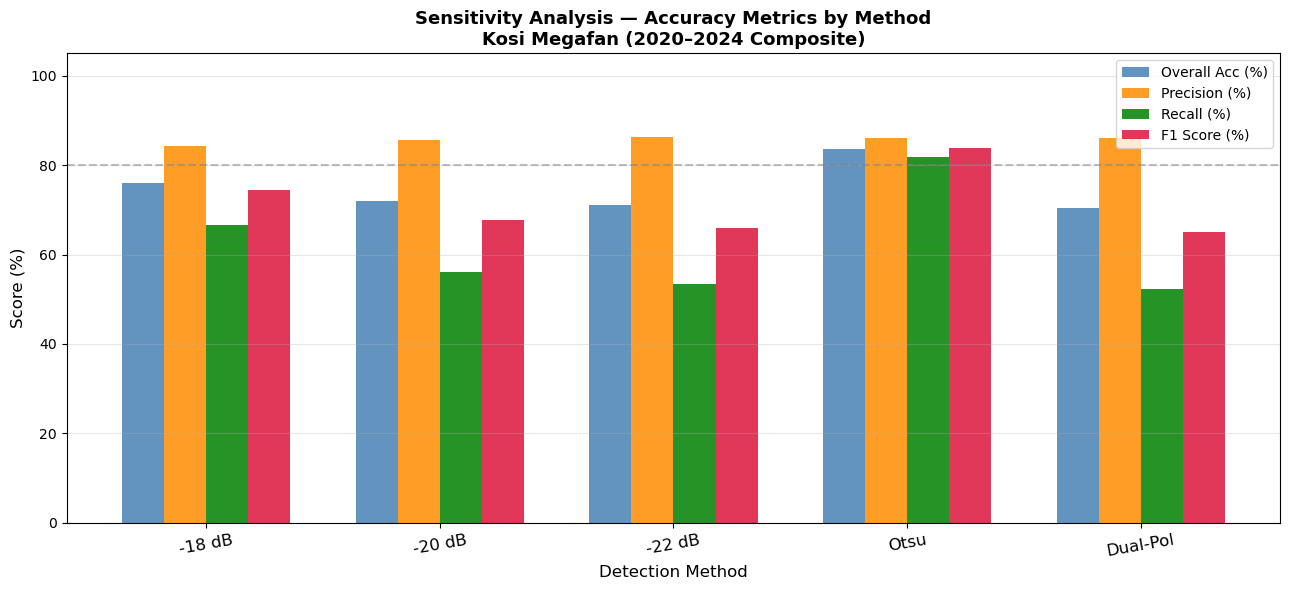

Saved plots to: D:\Research\Flood Susceptibility\Data\Rasters\output


In [49]:
# Plot metric comparison

metrics  = ['Overall Acc (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']
x        = np.arange(len(df))
width    = 0.18
colors   = ['steelblue', 'darkorange', 'green', 'crimson']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Detection Method', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Sensitivity Analysis — Accuracy Metrics by Method\nKosi Megafan (2020–2024 Composite)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df['Method'], rotation=10, fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 105)
ax.axhline(y=80, color='grey', linestyle='--', alpha=0.5, label='80% reference line')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'sensitivity_analysis_metrics.png', dpi=600, bbox_inches='tight')
plt.show()
print(f"Saved plots to: {OUTPUT_DIR}")